In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Image processing
from PIL import Image
import cv2
from skimage.feature import hog

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
DATA_DIR = "C:/Users/DELL/Fashion Image Classifier/Fashion Product Images (Small)"
IMAGES_DIR = os.path.join(DATA_DIR, "images")
STYLES_PATH = os.path.join(DATA_DIR, "styles.csv")

os.makedirs('../models', exist_ok=True)

MAX_IMAGES = 8000  
IMAGE_SIZE = (80, 60)  # Width, Height


if os.path.exists(IMAGES_DIR):
    image_files = os.listdir(IMAGES_DIR)
    print(f"Number of images: {len(image_files)}")

Number of images: 44441


In [3]:
# Load the styles data
try:
    styles_df = pd.read_csv(STYLES_PATH, on_bad_lines='skip')
    print("Styles data loaded successfully!")
except Exception as e:
    print(f"Error loading styles.csv: {e}")

    styles_df = pd.read_csv(STYLES_PATH, on_bad_lines='skip', encoding='latin-1')


print("\nDataset Overview:")
print(f"Total number of products: {len(styles_df)}")
print(f"Number of columns: {len(styles_df.columns)}")
print(f"Columns: {styles_df.columns.tolist()}")

print("\nFirst few rows:")
display(styles_df.head())

print("\nData types and missing values:")
styles_df.info()

Styles data loaded successfully!

Dataset Overview:
Total number of products: 44424
Number of columns: 10
Columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']

First few rows:


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt



Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  object 
 2   masterCategory      44424 non-null  object 
 3   subCategory         44424 non-null  object 
 4   articleType         44424 non-null  object 
 5   baseColour          44409 non-null  object 
 6   season              44403 non-null  object 
 7   year                44423 non-null  float64
 8   usage               44107 non-null  object 
 9   productDisplayName  44417 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.4+ MB


In [4]:
# Check if required columns exist
required_columns = ['id', 'articleType']
missing_columns = [col for col in required_columns if col not in styles_df.columns]

if missing_columns:
    print(f"Missing columns: {missing_columns}")
    print("Available columns:", styles_df.columns.tolist())
else:
    print("All required columns present!")


if os.path.exists(IMAGES_DIR):
    image_files = os.listdir(IMAGES_DIR)
    print(f"Images directory found with {len(image_files)} files")

else:
    print(f"Images directory not found at: {IMAGES_DIR}")
    print("Please check your folder structure!")



All required columns present!
Images directory found with 44441 files


In [5]:
category_mapping = {
    # T-shirts and Shirts
    'Tshirts': 'Tshirts', 
    'Shirts': 'Shirts',
    
    # Dresses and similar
    'Dresses': 'Dresses', 
    'Kurtas': 'Dresses',
    
    # Shoes
    'Casual Shoes': 'Shoes', 
    'Sports Shoes': 'Shoes', 
    'Sandals': 'Shoes', 
    'Flats': 'Shoes',
    'Heels': 'Shoes',
    
    # Pants
    'Trousers': 'Pants', 
    'Jeans': 'Pants', 
    'Track Pants': 'Pants',
    'Shorts': 'Pants',
    
    # Jackets
    'Jackets': 'Jackets', 
    'Blazers': 'Jackets',
    'Waistcoats': 'Jackets',
    
    # Sweaters
    'Sweatshirts': 'Sweaters', 
    'Sweaters': 'Sweaters',
    'Cardigans': 'Sweaters',
    
    # Tops
    'Tops': 'Tops', 
    'Kurtis': 'Tops',
    'Blouses': 'Tops'
}

print("Category mapping defined:")
for key, value in category_mapping.items():
    print(f"  {key} → {value}")

# Apply category mapping
styles_df['simple_category'] = styles_df['articleType'].map(category_mapping)

# Check mapping results
print(f"\nOriginal categories: {styles_df['articleType'].nunique()}")
print(f"Mapped categories: {styles_df['simple_category'].nunique()}")

# Show value counts before and after
print("\nTop 10 original categories:")
print(styles_df['articleType'].value_counts().head(10))

print("\nMapped categories:")
category_counts = styles_df['simple_category'].value_counts()
print(category_counts)

# Remove rows that couldn't be mapped
original_count = len(styles_df)
styles_df = styles_df.dropna(subset=['simple_category'])
print(f"\nRemoved {original_count - len(styles_df)} unmapped rows")
print(f"Remaining products: {len(styles_df)}")

Category mapping defined:
  Tshirts → Tshirts
  Shirts → Shirts
  Dresses → Dresses
  Kurtas → Dresses
  Casual Shoes → Shoes
  Sports Shoes → Shoes
  Sandals → Shoes
  Flats → Shoes
  Heels → Shoes
  Trousers → Pants
  Jeans → Pants
  Track Pants → Pants
  Shorts → Pants
  Jackets → Jackets
  Blazers → Jackets
  Waistcoats → Jackets
  Sweatshirts → Sweaters
  Sweaters → Sweaters
  Cardigans → Sweaters
  Tops → Tops
  Kurtis → Tops
  Blouses → Tops

Original categories: 143
Mapped categories: 8

Top 10 original categories:
articleType
Tshirts         7067
Shirts          3217
Casual Shoes    2845
Watches         2542
Sports Shoes    2036
Kurtas          1844
Tops            1762
Handbags        1759
Heels           1323
Sunglasses      1073
Name: count, dtype: int64

Mapped categories:
simple_category
Shoes       7601
Tshirts     7067
Shirts      3217
Dresses     2308
Tops        1996
Pants       1990
Sweaters     562
Jackets      266
Name: count, dtype: int64

Removed 19417 unmapped r

Selected top 8 categories:
  1. Shoes: 7601 products
  2. Tshirts: 7067 products
  3. Shirts: 3217 products
  4. Dresses: 2308 products
  5. Tops: 1996 products
  6. Pants: 1990 products
  7. Sweaters: 562 products
  8. Jackets: 266 products

Total products in filtered dataset: 25007
Categories selected: ['Shoes', 'Tshirts', 'Shirts', 'Dresses', 'Tops', 'Pants', 'Sweaters', 'Jackets']


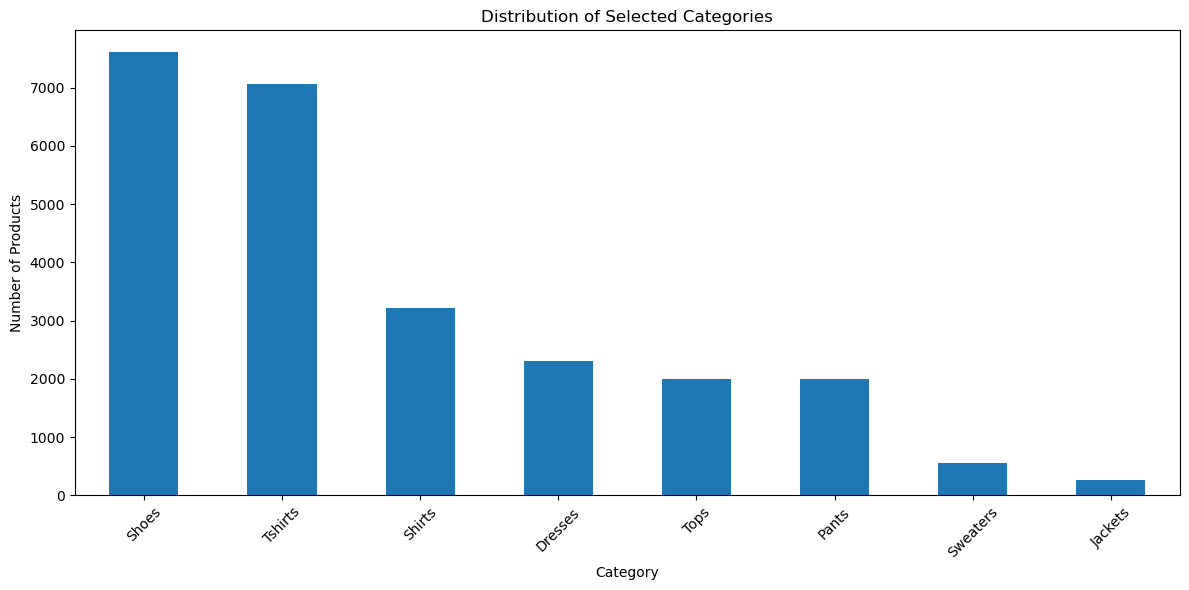

In [6]:
TOP_CATEGORY_COUNT = 8
top_categories = category_counts.head(TOP_CATEGORY_COUNT).index
filtered_df = styles_df[styles_df['simple_category'].isin(top_categories)]

print(f"Selected top {TOP_CATEGORY_COUNT} categories:")
for i, category in enumerate(top_categories, 1):
    count = category_counts[category]
    print(f"  {i}. {category}: {count} products")

print(f"\nTotal products in filtered dataset: {len(filtered_df)}")
print(f"Categories selected: {list(top_categories)}")



plt.figure(figsize=(12, 6))
category_counts[top_categories].plot(kind='bar')
plt.title('Distribution of Selected Categories')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
def load_and_preprocess_images(df, images_dir, max_images=MAX_IMAGES, img_size=IMAGE_SIZE):
   
   # This func eturns images array, labels array, valid_ids list

    images = []
    labels = []
    valid_ids = []
    skipped_count = 0
    
    print(f"Loading up to {max_images} images...")
    
    for idx, row in df.iterrows():
        if len(images) >= max_images:
            break
            
        img_id = row['id']
        img_path = os.path.join(images_dir, f"{img_id}.jpg")
        
        if os.path.exists(img_path):
            try:
 
                with Image.open(img_path) as img:
                    # Convert to RGB if not already
                    if img.mode != 'RGB':
                        img = img.convert('RGB')
                    
                    # Resize image
                    img_resized = img.resize(img_size)
                    
                    # Convert to numpy array and normalize
                    img_array = np.array(img_resized) / 255.0
                    
                    images.append(img_array)
                    labels.append(row['simple_category'])
                    valid_ids.append(img_id)
                    
            except Exception as e:
                skipped_count += 1
                continue
        else:
            skipped_count += 1
    
    print(f"Successfully loaded {len(images)} images")
    print(f"Skipped {skipped_count} images")
    
    return np.array(images), np.array(labels), valid_ids

# Loading the images
print("Starting image loading...")
X_images, y_labels, valid_ids = load_and_preprocess_images(filtered_df, IMAGES_DIR)

print(f"\nFinal dataset shape:")
print(f"Images: {X_images.shape}") 
print(f"Labels: {y_labels.shape}")
print(f"Unique labels: {np.unique(y_labels)}")

Starting image loading...
Loading up to 8000 images...
Successfully loaded 8000 images
Skipped 1 images

Final dataset shape:
Images: (8000, 60, 80, 3)
Labels: (8000,)
Unique labels: ['Dresses' 'Jackets' 'Pants' 'Shirts' 'Shoes' 'Sweaters' 'Tops' 'Tshirts']


Sample images from each category:


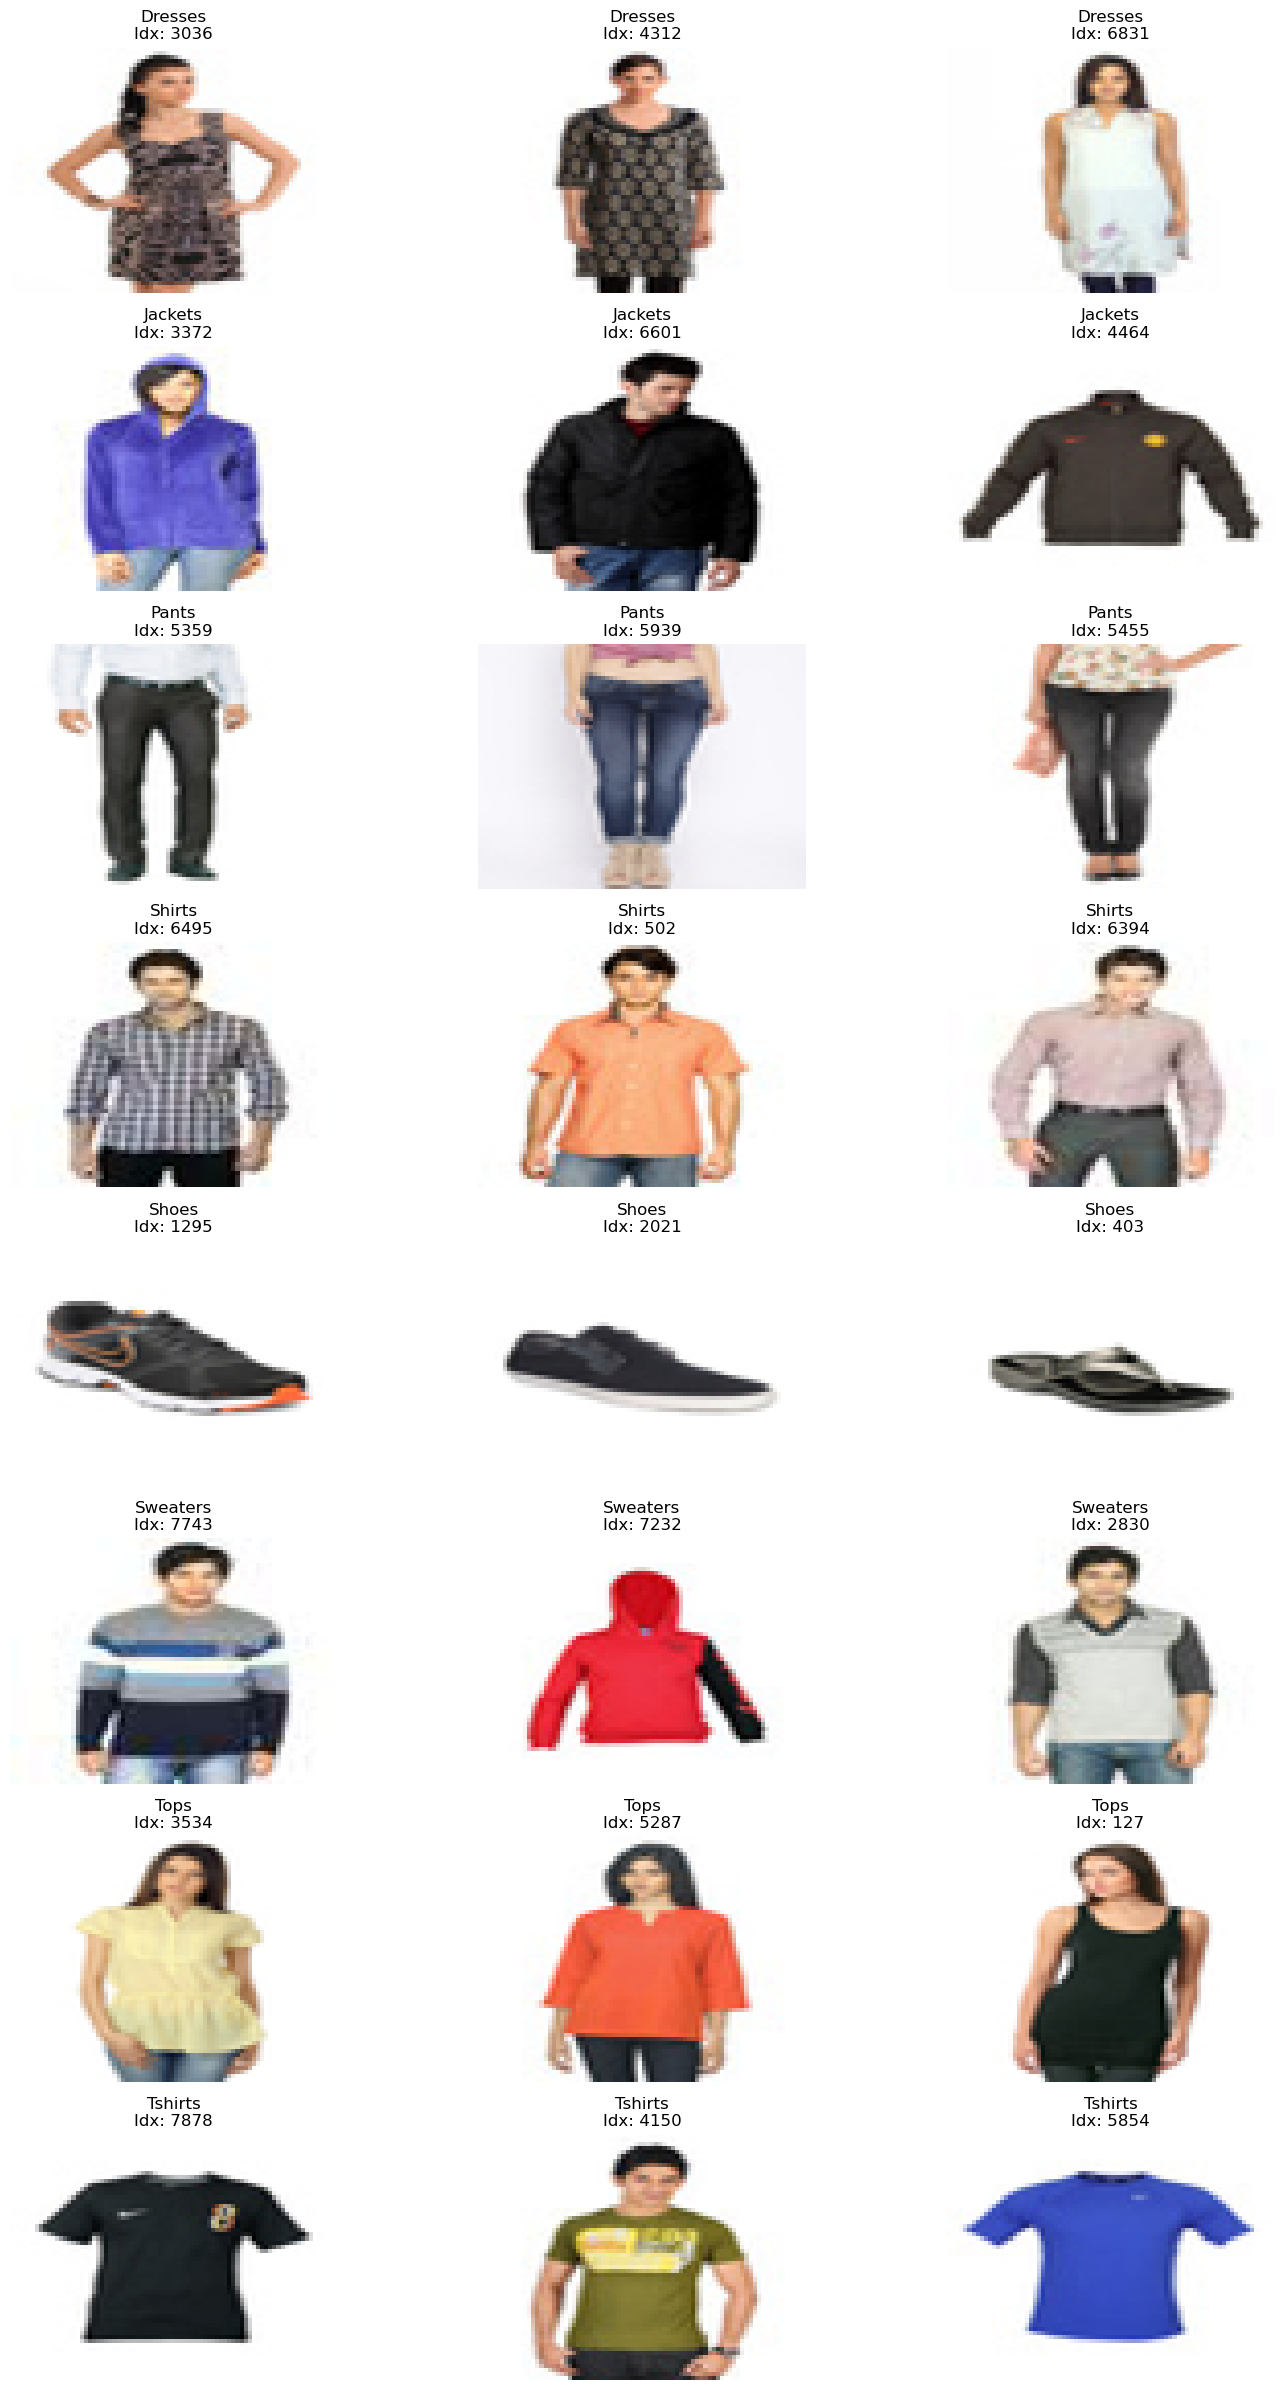

In [8]:
def display_sample_images(images, labels, samples_per_category=3):
    unique_categories = np.unique(labels)
    
    fig, axes = plt.subplots(len(unique_categories), samples_per_category, 
                            figsize=(15, 3*len(unique_categories)))
    
    if len(unique_categories) == 1:
        axes = axes.reshape(1, -1)
    
    for i, category in enumerate(unique_categories):
        # Get indices of this category
        category_indices = np.where(labels == category)[0]
        
        # Sample random images from this category
        if len(category_indices) > samples_per_category:
            sample_indices = np.random.choice(category_indices, samples_per_category, replace=False)
        else:
            sample_indices = category_indices
        
        for j, idx in enumerate(sample_indices):
            if j < samples_per_category:
                ax = axes[i, j] if len(unique_categories) > 1 else axes[j]
                ax.imshow(images[idx])
                ax.set_title(f'{category}\nIdx: {idx}')
                ax.axis('off')
    
    plt.tight_layout()
    plt.show()

print("Sample images from each category:")
display_sample_images(X_images, y_labels)

In [9]:
# Encode labels to numerical values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

print("Label encoding mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {i}: {class_name}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X_images, y_encoded, valid_ids, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print(f"\nData split completed:")
print(f"Training set: {X_train.shape[0]} images")
print(f"Testing set: {X_test.shape[0]} images")
print(f"Total categories: {len(label_encoder.classes_)}")

# Save the pkl of label encoder
joblib.dump(label_encoder, '../models/label_encoder.pkl')
print("Label encoder saved!")

Label encoding mapping:
  0: Dresses
  1: Jackets
  2: Pants
  3: Shirts
  4: Shoes
  5: Sweaters
  6: Tops
  7: Tshirts

Data split completed:
Training set: 6400 images
Testing set: 1600 images
Total categories: 8
Label encoder saved!


In [10]:
# Saving processed data for later use
processed_data = {
    'X_train': X_train,
    'X_test': X_test, 
    'y_train': y_train,
    'y_test': y_test,
    'label_encoder': label_encoder,
    'category_names': label_encoder.classes_,
    'image_shape': IMAGE_SIZE
}

joblib.dump(processed_data, '../models/processed_data.pkl')

print("Processed data saved successfully!")

print(f"Final dataset ready for feature engineering:")
print(f"  - Training images: {X_train.shape}")
print(f"  - Test images: {X_test.shape}")
print(f"  - Categories: {list(label_encoder.classes_)}")

Processed data saved successfully!
Final dataset ready for feature engineering:
  - Training images: (6400, 60, 80, 3)
  - Test images: (1600, 60, 80, 3)
  - Categories: [np.str_('Dresses'), np.str_('Jackets'), np.str_('Pants'), np.str_('Shirts'), np.str_('Shoes'), np.str_('Sweaters'), np.str_('Tops'), np.str_('Tshirts')]
